# Нейронная сеть прямого распространения — Классификация

**Нейронная сеть прямого распространения (Feedforward Neural Network)** передаёт данные от входного слоя через скрытые слои к выходному без обратных связей. Каждый нейрон вычисляет взвешенную сумму входов и применяет функцию активации. Обучение ведётся методом **обратного распространения ошибки** (backpropagation) с оптимизатором **Adam**. Для задачи бинарной классификации используются функции активации ReLU (скрытые слои) и Sigmoid (выход).

**Датасет:** Heart Disease UCI — клинические показатели пациентов, цель — предсказать наличие болезни сердца.

## 2. Используемые библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
tf.random.set_seed(42); np.random.seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 3. Описание и демонстрация датасета

In [2]:
df = pd.read_csv('./heart.csv')
print("Форма датасета:", df.shape)
print("\nПервые 10 строк:")
print(df.head(10).to_string())
print("\nОписательная статистика:")
print(df.describe().round(2).to_string())
print("\nПропущенные значения:", df.isnull().sum().sum())
print("\nРаспределение целевой переменной:")
print(df['HeartDisease'].value_counts().rename({0:'Болен (0)', 1:'Здоров (1)'}))

Форма датасета: (918, 12)

Первые 10 строк:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease
0   40   M           ATA        140          289          0     Normal    172              N      0.0       Up             0
1   49   F           NAP        160          180          0     Normal    156              N      1.0     Flat             1
2   37   M           ATA        130          283          0         ST     98              N      0.0       Up             0
3   48   F           ASY        138          214          0     Normal    108              Y      1.5     Flat             1
4   54   M           NAP        150          195          0     Normal    122              N      0.0       Up             0
5   39   M           NAP        120          339          0     Normal    170              N      0.0       Up             0
6   45   F           ATA        130          237          0     Normal    170    

## 4. Предварительная обработка

In [3]:
# Категориальные признаки → One-Hot Encoding
cat_cols = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']
df_enc   = pd.get_dummies(df, columns=cat_cols, drop_first=True)

X = df_enc.drop('HeartDisease', axis=1).values
y = df_enc['HeartDisease'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Признаков после кодирования: {X.shape[1]}")
print(f"Train: {X_train_sc.shape},  Test: {X_test_sc.shape}")
print(f"Доля классов (train): {np.bincount(y_train) / len(y_train)}")

Признаков после кодирования: 15
Train: (734, 15),  Test: (184, 15)
Доля классов (train): [0.44686649 0.55313351]


## 5. Тепловая карта корреляций

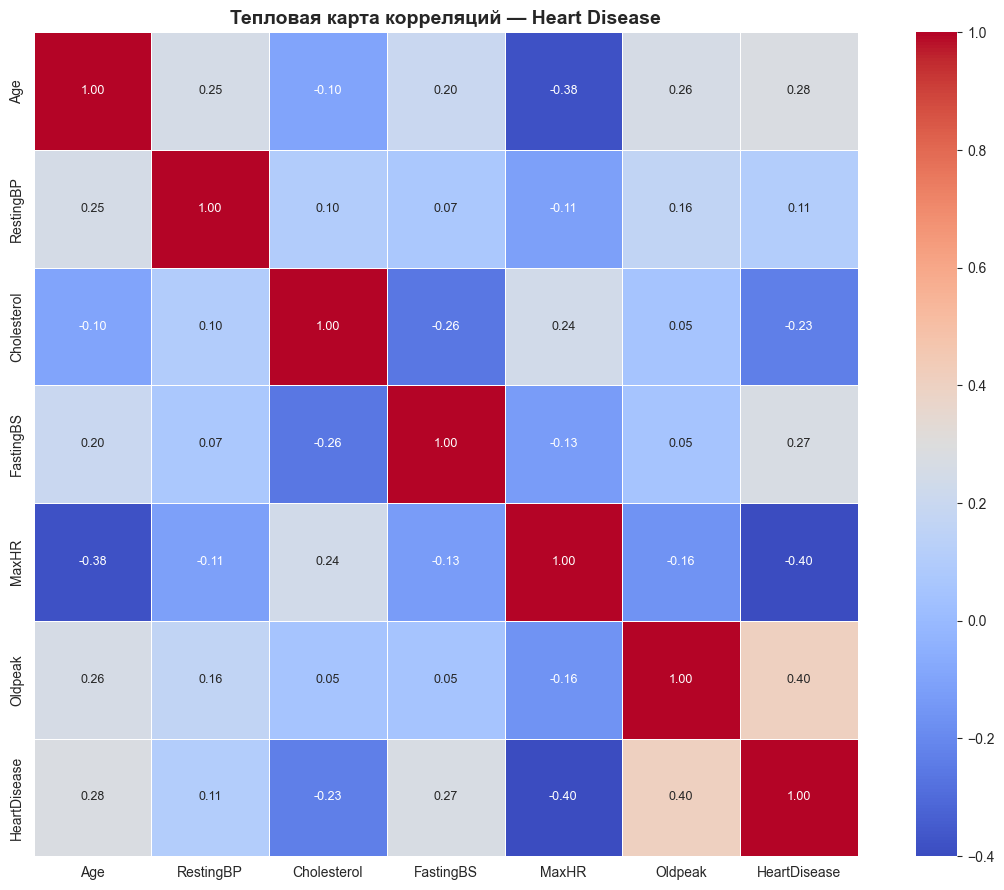

In [4]:
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, annot_kws={'size':9})
plt.title('Тепловая карта корреляций — Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Обучение нейронной сети

In [5]:
model = keras.Sequential([
    layers.Input(shape=(X_train_sc.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
], name='HeartDisease_NN')

model.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])
model.summary()

Model: "HeartDisease_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,697 (53.50 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_auc', mode='max'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=10, verbose=0)
]
history = model.fit(X_train_sc, y_train, epochs=300, batch_size=16,
                    validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5980 - auc: 0.6654 - loss: 0.6555 - val_accuracy: 0.8027 - val_auc: 0.8274 - val_loss: 0.6209 - learning_rate: 0.0010
Epoch 2/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7751 - auc: 0.8635 - loss: 0.4677 - val_accuracy: 0.8027 - val_auc: 0.8478 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 3/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8058 - auc: 0.8883 - loss: 0.4161 - val_accuracy: 0.8163 - val_auc: 0.8591 - val_loss: 0.4797 - learning_rate: 0.0010
Epoch 4/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8296 - auc: 0.9138 - loss: 0.3682 - val_accuracy: 0.8367 - val_auc: 0.8635 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 5/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8296 - auc: 0.9239 - loss: 0.3485 - val_accuracy: 0.8163 - val_auc: 0.8662 - val_loss: 0.4413 - learning_rate: 0.0010
Epoch 6/300
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8569 - auc: 0.9326 -

## 7. Прогнозы модели

In [7]:
y_prob = model.predict(X_test_sc, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("Отчёт классификации:")
print(classification_report(y_test, y_pred, target_names=['Здоров','Болен']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

res = pd.DataFrame({'Истинная_метка': y_test, 'Вероятность': y_prob.round(3), 'Предсказание': y_pred})
print("\nПервые 15 прогнозов:")
print(res.head(15).to_string())

Отчёт классификации:
              precision    recall  f1-score   support

      Здоров       0.89      0.88      0.88        82
       Болен       0.90      0.91      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.90       184
weighted avg       0.90      0.90      0.90       184

ROC-AUC: 0.9554

Первые 15 прогнозов:
    Истинная_метка  Вероятность  Предсказание
0                1        0.999             1
1                1        0.630             1
2                1        0.988             1
3                1        0.388             0
4                0        0.120             0
5                0        0.090             0
6                0        0.000             0
7                1        0.923             1
8                0        0.000             0
9                1        0.999             1
10               1        0.997             1
11               0        0.000             0
12              

## 8. Графики результатов

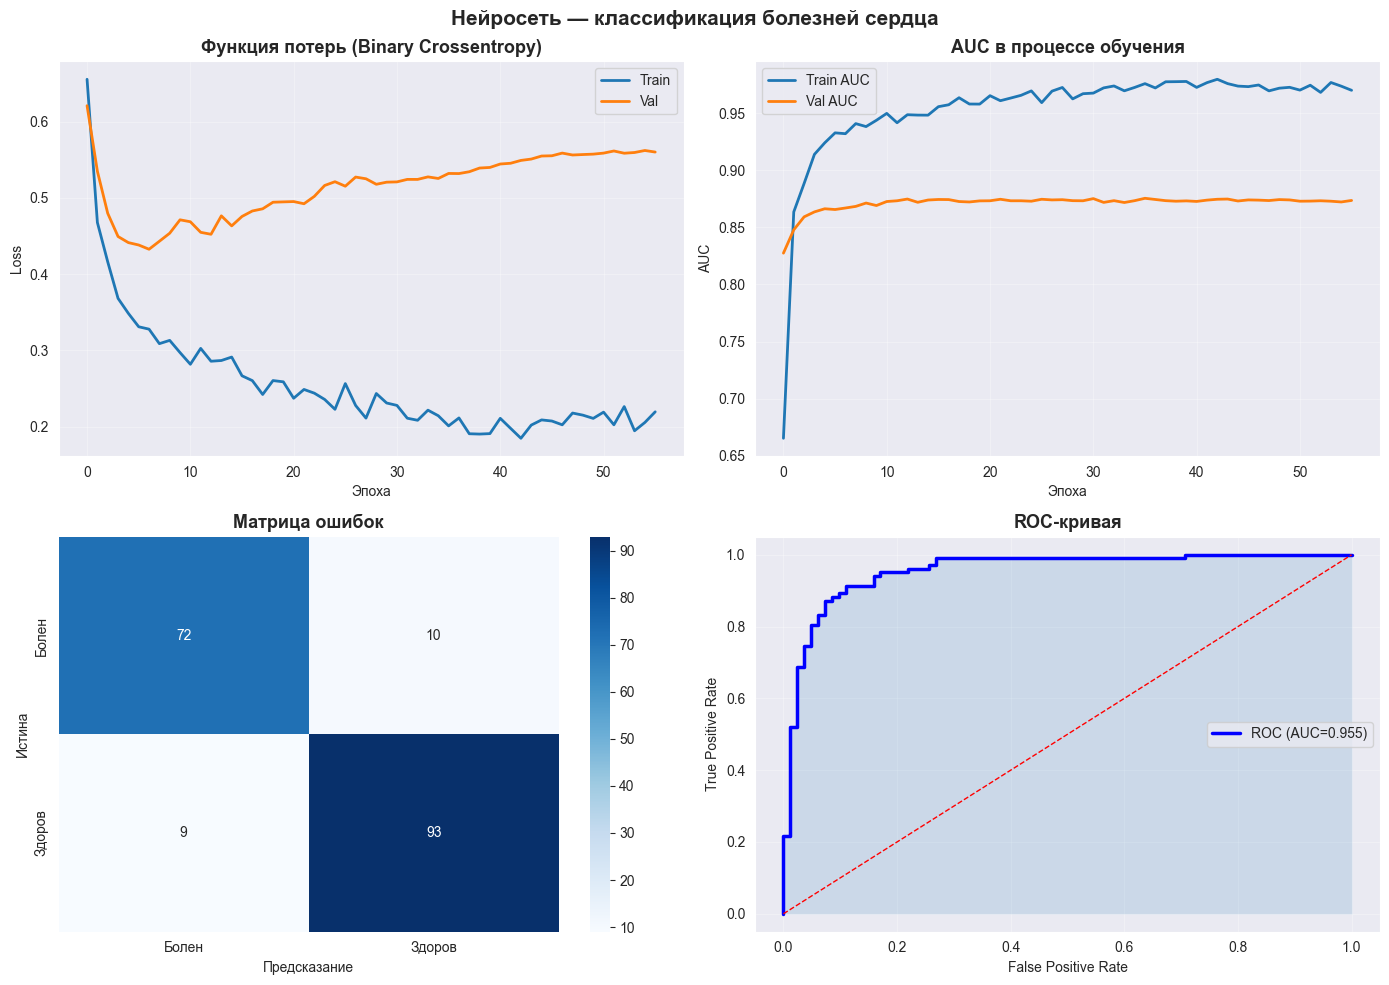

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0,0].plot(history.history['loss'],     label='Train', linewidth=2)
axes[0,0].plot(history.history['val_loss'], label='Val',   linewidth=2)
axes[0,0].set_title('Функция потерь (Binary Crossentropy)', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('Эпоха'); axes[0,0].set_ylabel('Loss')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# AUC
axes[0,1].plot(history.history['auc'],     label='Train AUC', linewidth=2)
axes[0,1].plot(history.history['val_auc'], label='Val AUC',   linewidth=2)
axes[0,1].set_title('AUC в процессе обучения', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Эпоха'); axes[0,1].set_ylabel('AUC')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Болен','Здоров'], yticklabels=['Болен','Здоров'])
axes[1,0].set_title('Матрица ошибок', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Предсказание'); axes[1,0].set_ylabel('Истина')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_val = roc_auc_score(y_test, y_prob)
axes[1,1].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'ROC (AUC={auc_val:.3f})')
axes[1,1].fill_between(fpr, tpr, alpha=0.15)
axes[1,1].plot([0,1],[0,1],'r--',linewidth=1)
axes[1,1].set_title('ROC-кривая', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('False Positive Rate'); axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Нейросеть — классификация болезней сердца', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()